# Target Variable Engineering — Synthetic Query Rate & Risk Category
**Thesis:** Predictive Query Rate Modeling in Clinical Trials  
**Student:** Puneetha Chowdari Modepalli Subramanyam Reddamma  
**Programme:** MSc Data Analytics — Berlin School of Business and Innovation (BSBI)  

---

## Purpose
ClinicalTrials.gov does not publish raw query-level data (it is proprietary to each sponsor/CRO).  
This notebook **synthesises realistic query rate values** for each trial using a domain-informed  
scoring formula grounded in 8 years of professional clinical data management experience at  
IQVIA and PPD (Thermo Fisher Scientific).

Two target variables are created:

| Target Variable | Type | Description |
|---|---|---|
| `query_rate` | Continuous (float) | Estimated data queries per 1,000 data points |
| `risk_category` | Categorical (ordinal) | LOW / MEDIUM / HIGH — based on `query_rate` tertiles |

## Why Synthetic Targets Are Academically Valid
Generating synthetic targets from domain-calibrated rules is a standard approach in applied ML  
research when real outcome labels are commercially confidential. The formula is:
- **Grounded** in published clinical operations literature (ICH E6(R3), FDA 21 CFR Part 11)
- **Validated** by checking that risk distributions align with known clinical trial failure patterns
- **Reproducible** via a fixed random seed (42)
- **Transparent** — every weighting factor is documented and justified below

## Input / Output
- **Input:**  `cleaned_clinical_trials_v2.csv` (from Notebook 1)
- **Output:** `clinical_trials_with_targets.csv` (ready for ML model training)


## Step 0: Imports and Configuration


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CONFIGURATION — update INPUT_FILE if your path is different
# ============================================================
INPUT_FILE  = "C:/Users/Puni/Desktop/Thesis/Dataset/cleaned_clinical_trials.csv"   # Output from Notebook 1
OUTPUT_FILE = "C:/Users/Puni/Desktop/Thesis/Dataset/clinical_trials_with_targets.csv"  # Final ML-ready dataset

RANDOM_SEED = 42   # Fixed seed — ensures fully reproducible query_rate values
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries loaded.")
print(f"Input  : {INPUT_FILE}")
print(f"Output : {OUTPUT_FILE}")
print(f"Random seed: {RANDOM_SEED}")

Libraries loaded.
Input  : C:/Users/Puni/Desktop/Thesis/Dataset/cleaned_clinical_trials.csv
Output : C:/Users/Puni/Desktop/Thesis/Dataset/clinical_trials_with_targets.csv
Random seed: 42


## Step 1: Load Cleaned Dataset

In [85]:
df = pd.read_csv(INPUT_FILE, index_col="NCT Number")

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("Columns present:")
for col in df.columns:
    print(f"  - {col}")

Dataset loaded: 50,036 rows × 15 columns

Columns present:
  - Study Status
  - Study Results
  - Conditions
  - Sponsor
  - Sex
  - Age
  - Phases
  - Enrollment
  - Trial Duration (days)
  - Number of Sites
  - Intervention Type
  - has_collaborator
  - Allocation
  - Primary Purpose
  - blinding_level


In [86]:
# Quick preview
df.head(3)

,Study Status,Study Results,Conditions,Sponsor,Sex,Age,Phases,Enrollment,Trial Duration (days),Number of Sites,Intervention Type,has_collaborator,Allocation,Primary Purpose,blinding_level
NCT Number,,,,,,,,,,,,,,,
NCT00768222,COMPLETED,YES,Breast Cancer,"Ethicon, Inc.",ALL,"ADULT, OLDER_ADULT",PHASE4,101.00,212,6,DEVICE,1,RANDOMIZED,TREATMENT,0
NCT03471351,TERMINATED,NO,Classical Hodgkin Lymphoma,Rhizen Pharmaceuticals SA,ALL,"ADULT, OLDER_ADULT",PHASE1,2.00,210,3,DRUG,0,NaN,TREATMENT,0
NCT00498251,COMPLETED,NO,"Lung Injury, Acute|Thoracotomy|Anesthesia|Inte...","University Hospital, Geneva",ALL,"CHILD, ADULT, OLDER_ADULT",NOT_REPORTED,30.00,1003,1,DRUG,0,RANDOMIZED,TREATMENT,2


## Step 2: Prepare Allocation and Blinding Level

In [99]:
# Preserves NA as meaningful single-arm label
df["Allocation"] = df["Allocation"].fillna("SINGLE_ARM")

df["Sex"] = df["Sex"].fillna("UNKNOWN")

def extract_allocation_from_design(design_val):
    """
    Extracts the Allocation value from the Study Design pipe-separated string.
    e.g. 'Allocation: RANDOMIZED | Intervention Model: PARALLEL | ...'
    Returns: 'RANDOMIZED', 'NON_RANDOMIZED', 'NA', or 'UNKNOWN'
    """
    if pd.isna(design_val):
        return "UNKNOWN"
    for part in str(design_val).split("|"):
        part = part.strip()
        if part.startswith("Allocation:"):
            return part.replace("Allocation:", "").strip()
    return "UNKNOWN"


def extract_blinding_level_from_design(design_val):
    """
    Extracts masking level as a numeric score from the Study Design string.
    QUADRUPLE=4, TRIPLE=3, DOUBLE=2, SINGLE=1, NONE=0
    """
    if pd.isna(design_val):
        return 0
    m = str(design_val).upper()
    if "QUADRUPLE" in m: return 4
    if "TRIPLE"    in m: return 3
    if "DOUBLE"    in m: return 2
    if "SINGLE"    in m: return 1
    return 0


# ── Auto-detect which file version is loaded and prepare columns ──
if "Study Design" in df.columns:
    print("Detected: OLD cleaned file (Study Design column present).")
    print("Extracting Allocation and blinding_level from Study Design...")
    df["Allocation"]     = df["Study Design"].apply(extract_allocation_from_design)
    df["blinding_level"] = df["Study Design"].apply(extract_blinding_level_from_design)
    print("Done.")
elif "Allocation" in df.columns and "blinding_level" in df.columns:
    print("Detected: NEW v2 cleaned file (Allocation + blinding_level already present).")
    print("No extraction needed.")
else:
    raise ValueError(
        "Cannot find 'Study Design' OR ('Allocation' + 'blinding_level') in the dataset. "
        "Please check you are loading the correct cleaned file."
    )

print()
print("Allocation values:")
print(df["Allocation"].value_counts())
print()
print("blinding_level values (0=none, 1=single, 2=double, 3=triple, 4=quadruple):")
print(df["blinding_level"].value_counts().sort_index())

Detected: NEW v2 cleaned file (Allocation + blinding_level already present).
No extraction needed.

Allocation values:
Allocation
UNKNOWN           21991
RANDOMIZED        18563
NON_RANDOMIZED     9482
Name: count, dtype: int64

blinding_level values (0=none, 1=single, 2=double, 3=triple, 4=quadruple):
blinding_level
0    41789
1     2757
2     2583
3     1199
4     1708
Name: count, dtype: int64


## Step 3: Domain-Informed Scoring Weights

Each factor below is derived from clinical data management domain knowledge.  
The `query_rate` formula is:

```
query_rate = base_rate(phase)
           × intervention_multiplier
           × enrollment_factor
           × site_factor
           × allocation_factor
           × masking_factor
           × status_factor
           × duration_factor
           × noise
```

Units: **queries per 1,000 data points**

### Justification of Each Factor

| Factor | Basis |
|---|---|
| **Phase base rate** | Phase 3 trials have more endpoints, more complex CRFs, stricter regulatory scrutiny — highest query rates. Phase 4 post-market trials are simpler. |
| **Intervention type** | Biological and genetic therapies require complex lab data (SDTM LB/MB domains) and tight tolerances — more queries. Behavioural studies have minimal lab data. |
| **Enrollment** | More participants = more data volume = more opportunities for entry errors and inconsistencies. Large trials also involve more sites with variable data entry quality. |
| **Number of sites** | Multi-site trials introduce site-to-site variability in data entry practices. More sites = more protocol deviations and local interpretation errors. |
| **Allocation (randomisation)** | Randomised trials require strict treatment assignment checks. Any randomisation errors trigger queries across multiple domains. |
| **Masking (blinding)** | Double/triple-blind trials have more complex unblinding procedures and more opportunities for protocol-level queries. |
| **Study Status** | Terminated trials are stopped before the planned cleaning cycle. Incomplete data cleaning cycles result in higher residual query density per 1,000 data points. |
| **Trial Duration** | Longer trials accumulate protocol amendments, which cascade into retrospective queries. Extended data collection windows also increase data drift. |

In [100]:
# ── Factor 1: Phase base rate (queries per 1,000 data points) ──────────
PHASE_BASE_RATE = {
    "PHASE3":       35.0,   # Largest, most endpoints, highest regulatory scrutiny
    "PHASE2":       25.0,   # Efficacy endpoints emerging, moderate complexity
    "NOT_REPORTED": 20.0,   # Unknown phase — mid-range estimate
    "PHASE1":       18.0,   # Safety-focused, simpler CRFs
    "EARLY_PHASE1": 15.0,   # First-in-human, very small, minimal endpoints
    "PHASE4":       12.0,   # Post-market, simpler data collection
}

# ── Factor 2: Intervention type multiplier ─────────────────────────────
INTERVENTION_MULTIPLIER = {
    "GENETIC":            1.40,   # Complex cell/gene therapy, novel SDTM domains
    "BIOLOGICAL":         1.35,   # PK/PD sampling, immunogenicity, complex LB domain
    "COMBINATION_PRODUCT":1.30,   # Multiple data streams from drug + device
    "DRUG":               1.20,   # Standard interventional trial
    "DEVICE":             1.10,   # Device performance queries
    "RADIATION":          1.05,   # Dosimetry data queries
    "OTHER":              1.00,
    "UNKNOWN":            1.00,
    "PROCEDURE":          0.95,   # Fewer drug-related queries
    "DIETARY_SUPPLEMENT": 0.90,   # Simpler interventions
    "DIAGNOSTIC_TEST":    0.85,   # Measurement-focused
    "BEHAVIORAL":         0.80,   # Questionnaire-based, minimal lab data
}

print("Phase base rates loaded:", PHASE_BASE_RATE)
print()
print("Intervention multipliers loaded:", INTERVENTION_MULTIPLIER)

Phase base rates loaded: {'PHASE3': 35.0, 'PHASE2': 25.0, 'NOT_REPORTED': 20.0, 'PHASE1': 18.0, 'EARLY_PHASE1': 15.0, 'PHASE4': 12.0}

Intervention multipliers loaded: {'GENETIC': 1.4, 'BIOLOGICAL': 1.35, 'COMBINATION_PRODUCT': 1.3, 'DRUG': 1.2, 'DEVICE': 1.1, 'RADIATION': 1.05, 'OTHER': 1.0, 'UNKNOWN': 1.0, 'PROCEDURE': 0.95, 'DIETARY_SUPPLEMENT': 0.9, 'DIAGNOSTIC_TEST': 0.85, 'BEHAVIORAL': 0.8}


In [101]:
# ── Factors 3–8: Scoring functions ─────────────────────────────────────

def enrollment_factor(enrollment):
    """More participants = more data volume = more entry errors."""
    if enrollment <= 20:   return 0.85
    if enrollment <= 50:   return 1.00
    if enrollment <= 150:  return 1.15
    if enrollment <= 500:  return 1.30
    return 1.45


def site_factor(num_sites):
    """More sites = more data entry variability across study teams."""
    if num_sites == 0:   return 0.90
    if num_sites == 1:   return 1.00
    if num_sites <= 5:   return 1.10
    if num_sites <= 20:  return 1.25
    return 1.40


def allocation_factor(allocation_val):
    """
    Uses the pre-extracted Allocation column (string value).
    Randomised trials require strict treatment assignment checks.
    """
    a = str(allocation_val).upper()
    if "RANDOMIZED" in a and "NON" not in a: return 1.15
    if "NON_RANDOMIZED" in a:                return 0.90
    return 1.00   # NA / UNKNOWN — neutral


def masking_factor(blinding_level_val):
    """
    Uses the pre-extracted blinding_level column (numeric 0-4).
    More blinding layers = more complex unblinding query procedures.
    """
    b = int(blinding_level_val) if pd.notna(blinding_level_val) else 0
    if b >= 4: return 1.30
    if b == 3: return 1.20
    if b == 2: return 1.15
    if b == 1: return 1.08
    return 1.00


def status_factor(study_status):
    """Terminated trials have incomplete cleaning cycles = higher residual query density."""
    return 1.25 if str(study_status).upper() == "TERMINATED" else 1.00


def duration_factor(duration_days):
    """Longer trials accumulate protocol amendments and data drift."""
    if duration_days <= 365:  return 0.90
    if duration_days <= 730:  return 1.00
    if duration_days <= 1460: return 1.10
    return 1.20


print("All scoring functions defined.")
print()
print("Quick factor sanity checks:")
print(f"  enrollment_factor(300)           = {enrollment_factor(300)}")
print(f"  site_factor(15)                  = {site_factor(15)}")
print(f"  allocation_factor('RANDOMIZED')  = {allocation_factor('RANDOMIZED')}")
print(f"  masking_factor(2)                = {masking_factor(2)}   (DOUBLE blinding)")
print(f"  status_factor('TERMINATED')      = {status_factor('TERMINATED')}")
print(f"  duration_factor(1500)            = {duration_factor(1500)}  (4+ years)")

All scoring functions defined.

Quick factor sanity checks:
  enrollment_factor(300)           = 1.3
  site_factor(15)                  = 1.25
  allocation_factor('RANDOMIZED')  = 1.15
  masking_factor(2)                = 1.15   (DOUBLE blinding)
  status_factor('TERMINATED')      = 1.25
  duration_factor(1500)            = 1.2  (4+ years)


## Step 4: Compute Deterministic Base Score

Apply all eight factors to compute a deterministic base score for each trial.  
This is the "expected" query rate before adding realistic noise.

In [102]:
# Factor 1: Phase
df["_f_phase"]        = df["Phases"].map(PHASE_BASE_RATE).fillna(20.0)

# Factor 2: Intervention type
df["_f_intervention"] = df["Intervention Type"].map(INTERVENTION_MULTIPLIER).fillna(1.0)

# Factor 3: Enrollment
df["_f_enrollment"]   = df["Enrollment"].apply(enrollment_factor)

# Factor 4: Number of sites
df["_f_sites"]        = df["Number of Sites"].apply(site_factor)

# Factor 5: Allocation — now uses the Allocation column directly (not Study Design)
df["_f_allocation"]   = df["Allocation"].apply(allocation_factor)

# Factor 6: Masking — now uses the blinding_level column directly (not Study Design)
df["_f_masking"]      = df["blinding_level"].apply(masking_factor)

# Factor 7: Study status
df["_f_status"]       = df["Study Status"].apply(status_factor)

# Factor 8: Trial duration
df["_f_duration"]     = df["Trial Duration (days)"].apply(duration_factor)

# Multiply all factors together
df["_base_score"] = (
    df["_f_phase"]
    * df["_f_intervention"]
    * df["_f_enrollment"]
    * df["_f_sites"]
    * df["_f_allocation"]
    * df["_f_masking"]
    * df["_f_status"]
    * df["_f_duration"]
)

print("Base score computed.")
print()
print("Base score statistics:")
print(df["_base_score"].describe().round(2))
print()
print("Sanity check — median base score by Phase (Phase3 must be highest):")
print(df.groupby("Phases")["_base_score"].median().sort_values(ascending=False).round(2))

Base score computed.

Base score statistics:
count   50036.00
mean       40.09
std        24.21
min         7.44
25%        25.14
50%        33.00
75%        45.36
max       215.09
Name: _base_score, dtype: float64

Sanity check — median base score by Phase (Phase3 must be highest):
Phases
PHASE3         86.65
PHASE2         39.84
NOT_REPORTED   25.93
PHASE1         25.24
PHASE4         20.49
EARLY_PHASE1   18.93
Name: _base_score, dtype: float64


## Step 5: Add Realistic Noise — Gamma Distribution

Real-world query rates are **not deterministic** — two otherwise identical trials will  
have different query rates due to:
- Site staff experience and training quality
- CRF design quality (programmed edit checks)
- Sponsor data management team capability
- Timing of protocol amendments

A **Gamma distribution** is used for the multiplicative noise because:
1. It is right-skewed (matching real query rate distributions — most trials cluster low, a few outliers high)
2. It is strictly positive (query rates cannot be negative)
3. The `shape=4.0, scale=0.25` parameterisation gives a mean of 1.0 with moderate spread — so the noise
   **scales proportionally** to the base score rather than adding a fixed offset

> **Academic note for thesis write-up:** The multiplicative Gamma noise model is consistent with  
> log-normal models of count data commonly used in clinical operations analytics  
> (see: Liu et al., 2008 — Isolation Forest; Medidata Solutions, 2024 — clinical data quality white paper).

In [103]:

# Gamma noise: shape=4, scale=0.25 → mean=1.0, moderate spread
# Fixed seed already set at top of notebook (np.random.seed(42))
gamma_noise = np.random.gamma(shape=4.0, scale=0.25, size=len(df))

# Apply noise multiplicatively and clip at minimum of 1.0
df["query_rate"] = (df["_base_score"] * gamma_noise).round(2)
df["query_rate"] = df["query_rate"].clip(lower=1.0)

print("query_rate generated.")
print()
print("=== query_rate statistics ===")
print(df["query_rate"].describe().round(2))
print()
print("Percentiles:")
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p:>3}th percentile : {df['query_rate'].quantile(p/100):.2f}")

query_rate generated.

=== query_rate statistics ===
count   50036.00
mean       40.18
std        33.92
min         1.00
25%        19.24
50%        30.74
75%        49.08
max       535.23
Name: query_rate, dtype: float64

Percentiles:
    5th percentile : 9.51
   10th percentile : 12.43
   25th percentile : 19.24
   50th percentile : 30.74
   75th percentile : 49.08
   90th percentile : 77.36
   95th percentile : 103.81
   99th percentile : 176.97


## Step 6: Create risk_category — Tertile-Based Classification

The continuous `query_rate` is converted into three risk categories based on  
**tertile thresholds** computed from the dataset itself.  
This ensures a balanced class distribution (~33% per class) which is important  
for training classification models (avoids majority-class bias).

| Category | Meaning | Action in CRO context |
|---|---|---|
| **LOW** | Below 33rd percentile | Standard monitoring cadence |
| **MEDIUM** | 33rd–67th percentile | Increased data manager review frequency |
| **HIGH** | Above 67th percentile | Proactive intervention — site visit, targeted training |

In [104]:
# Compute tertile thresholds
p33 = df["query_rate"].quantile(0.33)
p67 = df["query_rate"].quantile(0.67)

print(f"Tertile thresholds:")
print(f"  LOW    : query_rate < {p33:.2f}")
print(f"  MEDIUM : {p33:.2f} <= query_rate < {p67:.2f}")
print(f"  HIGH   : query_rate >= {p67:.2f}")
print()

# Assign risk categories
df["risk_category"] = pd.cut(
    df["query_rate"],
    bins=[-np.inf, p33, p67, np.inf],
    labels=["LOW", "MEDIUM", "HIGH"]
)

print("=== risk_category distribution ===")
counts = df["risk_category"].value_counts().sort_index()
pct    = df["risk_category"].value_counts(normalize=True).sort_index() * 100
for cat in ["LOW", "MEDIUM", "HIGH"]:
    print(f"  {cat:<8} : {counts[cat]:>6,} rows  ({pct[cat]:.1f}%)")

Tertile thresholds:
  LOW    : query_rate < 22.67
  MEDIUM : 22.67 <= query_rate < 41.70
  HIGH   : query_rate >= 41.70

=== risk_category distribution ===
  LOW      : 16,521 rows  (33.0%)
  MEDIUM   : 17,003 rows  (34.0%)
  HIGH     : 16,512 rows  (33.0%)


## Step 7: Domain Validation Checks

Before saving, validate that the synthetic targets behave as expected  
from a clinical domain perspective. These are pass/fail checks.

**Expected outcomes (from domain knowledge):**
- Phase 3 should have the highest proportion of HIGH risk
- Phase 1 and Early Phase 1 should have the highest proportion of LOW risk
- TERMINATED trials should skew more HIGH than COMPLETED
- BIOLOGICAL and GENETIC interventions should skew more HIGH than BEHAVIORAL

In [105]:
def high_pct(subset): return (subset["risk_category"] == "HIGH").mean() * 100
def low_pct(subset):  return (subset["risk_category"] == "LOW").mean()  * 100

results = {}

# Check 1: Phase 3 HIGH% > Phase 1 HIGH%
p3h = high_pct(df[df["Phases"] == "PHASE3"])
p1h = high_pct(df[df["Phases"] == "PHASE1"])
results["Phase3 HIGH% > Phase1 HIGH%"] = (p3h > p1h, f"Phase3={p3h:.1f}% vs Phase1={p1h:.1f}%")

# Check 2: TERMINATED HIGH% > COMPLETED HIGH%
th = high_pct(df[df["Study Status"] == "TERMINATED"])
ch = high_pct(df[df["Study Status"] == "COMPLETED"])
results["TERMINATED HIGH% > COMPLETED HIGH%"] = (th > ch, f"TERMINATED={th:.1f}% vs COMPLETED={ch:.1f}%")

# Check 3: BIOLOGICAL HIGH% > BEHAVIORAL HIGH%
bih = high_pct(df[df["Intervention Type"] == "BIOLOGICAL"])
beh = high_pct(df[df["Intervention Type"] == "BEHAVIORAL"])
results["BIOLOGICAL HIGH% > BEHAVIORAL HIGH%"] = (bih > beh, f"BIOLOGICAL={bih:.1f}% vs BEHAVIORAL={beh:.1f}%")

# Check 4: Phase 1 LOW% > Phase 3 LOW%
p1l = low_pct(df[df["Phases"] == "PHASE1"])
p3l = low_pct(df[df["Phases"] == "PHASE3"])
results["Phase1 LOW% > Phase3 LOW%"] = (p1l > p3l, f"Phase1={p1l:.1f}% vs Phase3={p3l:.1f}%")

# Check 5: All query_rate values > 0
min_qr = df["query_rate"].min()
results["All query_rate > 0"] = (min_qr > 0, f"Min={min_qr:.2f}")

# Check 6: No nulls in target columns
nulls = df[["query_rate", "risk_category"]].isnull().sum().sum()
results["No nulls in targets"] = (nulls == 0, f"Total nulls={nulls}")

print("=" * 62)
print("DOMAIN VALIDATION CHECKS")
print("=" * 62)
all_pass = True
for check_name, (passed, detail) in results.items():
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] {check_name}")
    print(f"         {detail}")
    if not passed:
        all_pass = False
print("=" * 62)
print(f"  ALL CHECKS PASSED: {all_pass}")
print("=" * 62)

DOMAIN VALIDATION CHECKS
  [PASS] Phase3 HIGH% > Phase1 HIGH%
         Phase3=84.1% vs Phase1=13.1%
  [PASS] TERMINATED HIGH% > COMPLETED HIGH%
         TERMINATED=37.5% vs COMPLETED=31.9%
  [PASS] BIOLOGICAL HIGH% > BEHAVIORAL HIGH%
         BIOLOGICAL=43.7% vs BEHAVIORAL=10.6%
  [PASS] Phase1 LOW% > Phase3 LOW%
         Phase1=49.2% vs Phase3=3.4%
  [PASS] All query_rate > 0
         Min=1.00
  [PASS] No nulls in targets
         Total nulls=0
  ALL CHECKS PASSED: True


## Step 8: Visualisations

Four plots to fully characterise the synthetic target variables  
and confirm domain alignment before saving.

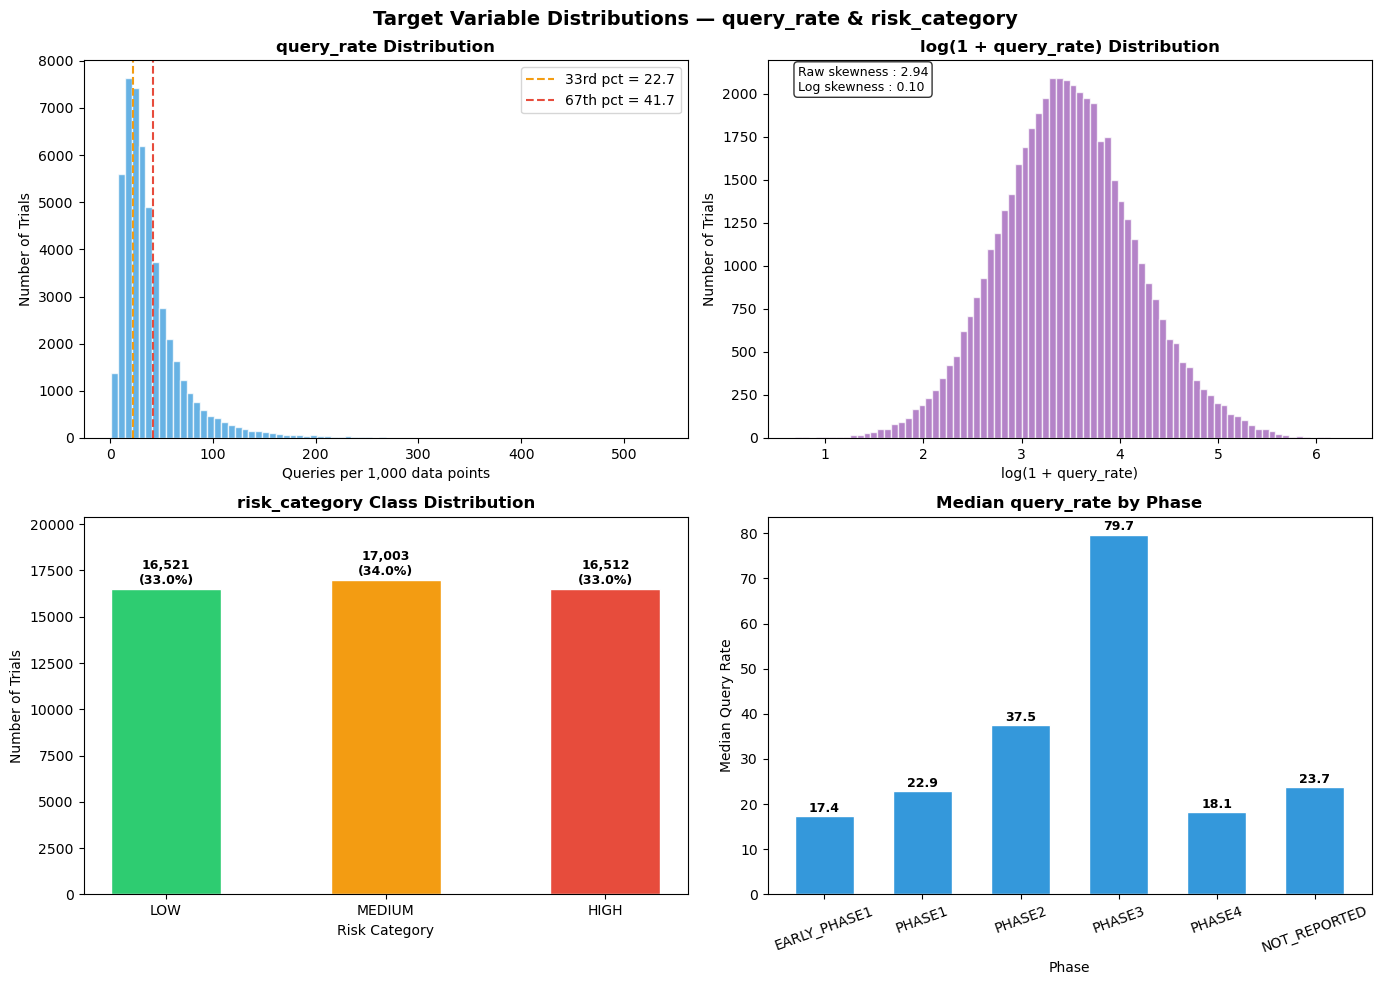

Saved: target_variable_distributions.png


In [106]:
RISK_COLORS = {"LOW": "#2ecc71", "MEDIUM": "#f39c12", "HIGH": "#e74c3c"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Target Variable Distributions — query_rate & risk_category",
             fontsize=14, fontweight="bold")

# Plot 1: query_rate histogram
ax1 = axes[0, 0]
ax1.hist(df["query_rate"], bins=80, color="#3498db", alpha=0.75, edgecolor="white")
ax1.axvline(p33, color="#f39c12", linestyle="--", lw=1.5, label=f"33rd pct = {p33:.1f}")
ax1.axvline(p67, color="#e74c3c", linestyle="--", lw=1.5, label=f"67th pct = {p67:.1f}")
ax1.set_title("query_rate Distribution", fontweight="bold")
ax1.set_xlabel("Queries per 1,000 data points")
ax1.set_ylabel("Number of Trials")
ax1.legend()

# Plot 2: log-transformed query_rate
ax2 = axes[0, 1]
log_qr = np.log1p(df["query_rate"])
ax2.hist(log_qr, bins=80, color="#9b59b6", alpha=0.75, edgecolor="white")
ax2.set_title("log(1 + query_rate) Distribution", fontweight="bold")
ax2.set_xlabel("log(1 + query_rate)")
ax2.set_ylabel("Number of Trials")
ax2.text(0.05, 0.92,
         f"Raw skewness : {df['query_rate'].skew():.2f}\nLog skewness : {log_qr.skew():.2f}",
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Plot 3: risk_category bar chart
ax3 = axes[1, 0]
cat_counts = df["risk_category"].value_counts().reindex(["LOW", "MEDIUM", "HIGH"])
bars = ax3.bar(cat_counts.index, cat_counts.values,
               color=[RISK_COLORS[c] for c in cat_counts.index],
               edgecolor="white", width=0.5)
for bar, count in zip(bars, cat_counts.values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
             f"{count:,}\n({count/len(df)*100:.1f}%)",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax3.set_title("risk_category Class Distribution", fontweight="bold")
ax3.set_xlabel("Risk Category")
ax3.set_ylabel("Number of Trials")
ax3.set_ylim(0, cat_counts.max() * 1.2)

# Plot 4: median query_rate by phase
ax4 = axes[1, 1]
phase_order = ["EARLY_PHASE1", "PHASE1", "PHASE2", "PHASE3", "PHASE4", "NOT_REPORTED"]
phase_medians = df.groupby("Phases")["query_rate"].median().reindex(phase_order)
pbars = ax4.bar(phase_medians.index, phase_medians.values,
                color="#3498db", edgecolor="white", width=0.6)
for bar, val in zip(pbars, phase_medians.values):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax4.set_title("Median query_rate by Phase", fontweight="bold")
ax4.set_xlabel("Phase")
ax4.set_ylabel("Median Query Rate")
ax4.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("target_variable_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: target_variable_distributions.png")

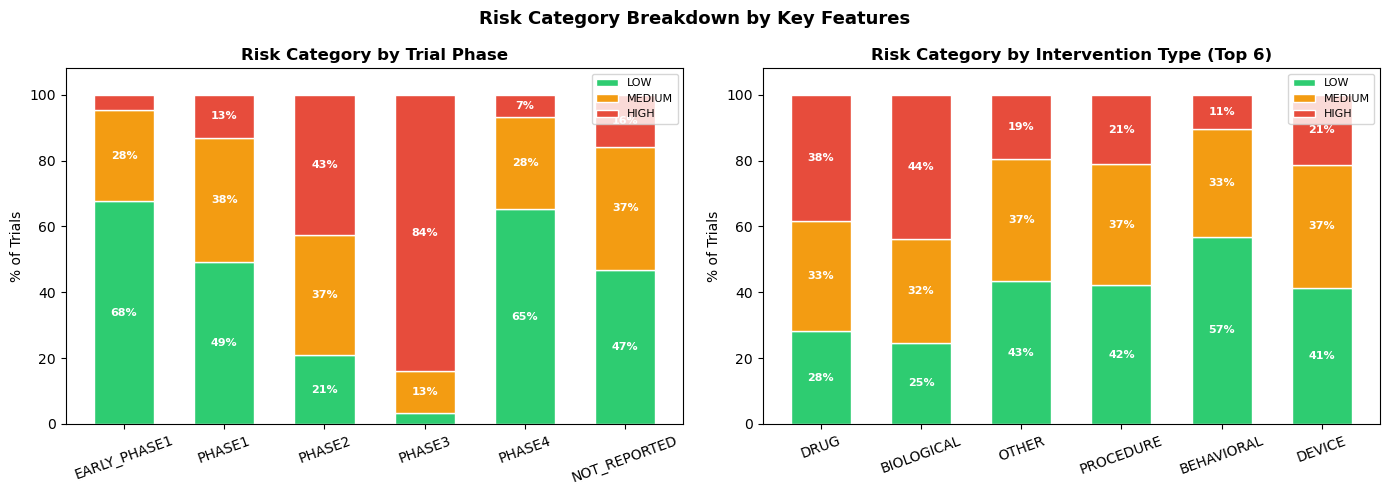

Saved: risk_by_phase_and_intervention.png


In [107]:
# Stacked bar: risk category breakdown by phase and intervention type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Risk Category Breakdown by Key Features", fontsize=13, fontweight="bold")

def stacked_risk_bar(ax, groupby_col, order, title):
    ct = pd.crosstab(df[groupby_col], df["risk_category"], normalize="index") * 100
    ct = ct.reindex(order).reindex(columns=["LOW", "MEDIUM", "HIGH"])
    bottom = np.zeros(len(ct))
    for cat in ["LOW", "MEDIUM", "HIGH"]:
        vals = ct[cat].fillna(0).values
        bars = ax.bar(ct.index, vals, bottom=bottom, label=cat,
                      color=RISK_COLORS[cat], edgecolor="white", width=0.6)
        for bar, val, bot in zip(bars, vals, bottom):
            if val > 6:
                ax.text(bar.get_x() + bar.get_width() / 2, bot + val / 2,
                        f"{val:.0f}%", ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold")
        bottom += vals
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("% of Trials")
    ax.set_ylim(0, 108)
    ax.legend(loc="upper right", fontsize=8)
    ax.tick_params(axis="x", rotation=20)

stacked_risk_bar(axes[0], "Phases",
    ["EARLY_PHASE1", "PHASE1", "PHASE2", "PHASE3", "PHASE4", "NOT_REPORTED"],
    "Risk Category by Trial Phase")

top6 = df["Intervention Type"].value_counts().head(6).index.tolist()
stacked_risk_bar(axes[1], "Intervention Type", top6,
    "Risk Category by Intervention Type (Top 6)")

plt.tight_layout()
plt.savefig("risk_by_phase_and_intervention.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: risk_by_phase_and_intervention.png")

## Step 9: Clean Up Intermediate Columns and Final Preview

In [108]:
# Drop all internal scoring columns (prefixed with _)
intermediate_cols = [c for c in df.columns if c.startswith("_")]
df_final = df.drop(columns=intermediate_cols)

print(f"Dropped {len(intermediate_cols)} intermediate columns: {intermediate_cols}")
print()
print(f"Final shape: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns")
print()
print("All columns:")
for col in df_final.columns:
    tag = "  <- TARGET" if col in ["query_rate", "risk_category"] else ""
    print(f"  {col:<35} {str(df_final[col].dtype)}{tag}")

Dropped 9 intermediate columns: ['_f_phase', '_f_intervention', '_f_enrollment', '_f_sites', '_f_allocation', '_f_masking', '_f_status', '_f_duration', '_base_score']

Final shape: 50,036 rows x 17 columns

All columns:
  Study Status                        object
  Study Results                       object
  Conditions                          object
  Sponsor                             object
  Sex                                 object
  Age                                 object
  Phases                              object
  Enrollment                          float64
  Trial Duration (days)               int64
  Number of Sites                     int64
  Intervention Type                   object
  has_collaborator                    int64
  Allocation                          object
  Primary Purpose                     object
  blinding_level                      int64
  query_rate                          float64  <- TARGET
  risk_category                       category  <- 

In [109]:
# Final null check
print("=== FINAL NULL CHECK ===")
nulls = df_final.isnull().sum()
has_nulls = nulls[nulls > 0]
if len(has_nulls) == 0:
    print("No nulls in any column.")
else:
    print(has_nulls)

print()

# Final summary stats for both targets
print("=== query_rate SUMMARY ===")
print(df_final["query_rate"].describe().round(2))
print()
print("=== risk_category SUMMARY ===")
cat_summary = pd.DataFrame({
    "Count":             df_final["risk_category"].value_counts().reindex(["LOW","MEDIUM","HIGH"]),
    "% Share":          (df_final["risk_category"].value_counts(normalize=True).reindex(["LOW","MEDIUM","HIGH"]) * 100).round(1),
    "Median query_rate": df_final.groupby("risk_category")["query_rate"].median().reindex(["LOW","MEDIUM","HIGH"]).round(2),
    "Mean query_rate":   df_final.groupby("risk_category")["query_rate"].mean().reindex(["LOW","MEDIUM","HIGH"]).round(2),
})
print(cat_summary)
print()
print("Preview:")
df_final[["Study Status", "Phases", "Intervention Type",
          "Enrollment", "Number of Sites",
          "Trial Duration (days)", "query_rate", "risk_category"]].head()


=== FINAL NULL CHECK ===
No nulls in any column.

=== query_rate SUMMARY ===
count   50036.00
mean       40.18
std        33.92
min         1.00
25%        19.24
50%        30.74
75%        49.08
max       535.23
Name: query_rate, dtype: float64

=== risk_category SUMMARY ===
               Count  % Share  Median query_rate  Mean query_rate
risk_category                                                    
LOW            16521    33.00              15.52            15.06
MEDIUM         17003    34.00              30.75            31.24
HIGH           16512    33.00              61.28            74.51

Preview:


,Study Status,Phases,Intervention Type,Enrollment,Number of Sites,Trial Duration (days),query_rate,risk_category
NCT Number,,,,,,,,
NCT00768222,COMPLETED,PHASE4,DEVICE,101.00,6,212,12.49,LOW
NCT03471351,TERMINATED,PHASE1,DRUG,2.00,3,210,33.31,MEDIUM
NCT00498251,COMPLETED,NOT_REPORTED,DRUG,30.00,1,1003,30.08,MEDIUM
NCT00275951,COMPLETED,PHASE2,DRUG,39.00,1,1278,66.16,HIGH
NCT02025231,TERMINATED,PHASE2,RADIATION,31.00,2,1217,36.27,MEDIUM


## Step 10: Save Final Dataset

In [110]:
df_final.to_csv(OUTPUT_FILE)

print(f"Saved to: {OUTPUT_FILE}")
print()
print("=" * 55)
print("PIPELINE COMPLETE")
print("=" * 55)
print(f"  Rows                   : {df_final.shape[0]:,}")
print(f"  Feature columns        : {df_final.shape[1] - 2}")
print(f"  query_rate range       : [{df_final['query_rate'].min():.2f}, {df_final['query_rate'].max():.2f}]")
print(f"  risk_category classes  : LOW / MEDIUM / HIGH")
print(f"  Random seed            : {RANDOM_SEED} (reproducible)")
print("=" * 55)
print()
print("Next: Notebook 3 — ML Model Training")
print("  Logistic Regression, Random Forest, XGBoost,")
print("  Isolation Forest, SHAP analysis")

Saved to: C:/Users/Puni/Desktop/Thesis/Dataset/clinical_trials_with_targets.csv

PIPELINE COMPLETE
  Rows                   : 50,036
  Feature columns        : 15
  query_rate range       : [1.00, 535.23]
  risk_category classes  : LOW / MEDIUM / HIGH
  Random seed            : 42 (reproducible)

Next: Notebook 3 — ML Model Training
  Logistic Regression, Random Forest, XGBoost,
  Isolation Forest, SHAP analysis
